# 🧠 Apa itu Regularization?

Regularization adalah teknik untuk mengurangi overfitting dengan menambahkan penalti (hukuman) pada besar koefisien model.

Tujuan utamanya:
- membuat model lebih sederhana
- mencegah koefisien menjadi terlalu besar
- meningkatkan generalisasi

Regularization hanya bekerja untuk model yang memiliki koefisien, misalnya:
- Linear Regression
- Logistic Regression
- SVM
- Neural Network (dengan weight decay)

## Contoh Sintaksis LaTex Umum
- Pangkat (Superscript): ^ (contoh: x^2 akan menjadi $x^2$)
- Indeks (Subscript): _ (contoh: x_i akan menjadi $ x_i $)
- Pecahan: \frac{arg1}{arg2} (contoh: \frac{1}{2} akan menjadi $ \frac{1}{2} $)
- Akar Kuadrat: \sqrt{arg} (contoh: \sqrt{x^2+y^2} akan menjadi $ \sqrt{x^2+y^2} $)
- Simbol Sigma (Penjumlahan): \sum_{i=1}^{n} (contoh: \sum_{i=1}^{n} i akan menjadi $ \sum_{i=1}^{n} i $) 

## 🟦 1. L2 Regularization (Ridge)

🔍 Intuisi

L2 menambahkan penalti berupa kuadrat koefisien:  
  
$ Lossridge​=loss+λ∑w2 $

🔸 Ciri khas:
- Mengecilkan koefisien → tetapi tidak membuatnya nol
- Mengatasi multicollinearity
- Lebih stabil untuk model linear

🧠 Efek:
- Menurunkan variance model
- Koefisien tetap kecil dan smooth
- Cocok ketika banyak fitur yang punya sedikit pengaruh

## 🟥 2. L1 Regularization (Lasso)

L1 menambahkan penalti berupa nilai absolut koefisien:  
  
  $$ 
  Losslasso​=loss+λ∑∣w∣ 
  $$

🔸 Ciri khas:
- Membuat beberapa koefisien nol → otomatis melakukan feature selectio
- Berguna ketika fitur sangat banyak

🧠 Efek:
- Model menjadi lebih sederhana
- Secara otomatis menghapus fitur tidak penting
- Bisa menjadi sparse model

## 🟧 3. ElasticNet (L1 + L2)

Gabungan L1 dan L2:  
$$
Loss=loss+α(λ_1​∑∣w∣+λ_2​∑w^2)
$$

**Digunakan jika:**
- ada banyak fitur saling berkorelasi (L2 membantu menstabilkan)
- ingin fitur selection (L1)

📘 Kapan Menggunakan Apa?  
| Regularization | Kapan digunakan |  
|L2 (Ridge)	| Banyak fitur saling berkorelasi / ingin model stabil |  
|L1 (Lasso)	| Fitur sangat banyak, dan ingin feature selection |  
|ElasticNet	| Kombinasi kebutuhan stabilitas + feature selection |  

## 🧪 CONTOH KODE PYTHON (Regresi)

### 🌟 BAGIAN 1 — CONTOH REGRESI DENGAN DATA DUMMY  
Kita buat dataset dummy untuk memprediksi harga rumah berdasarkan:
- luas_rumah
- jumlah_kamar
- usia_bangunan

### 📌 A. Membuat Data Dummy (Regresi)

In [40]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [41]:
# create dummy regression dataset
np.random.seed(42)
n = 1258

df = pd.DataFrame({
    "luas_rumah": np.random.randint(30, 150, n),
    "jumlah_kamar": np.random.randint(1, 6, n),
    "usia_bangunan": np.random.randint(1, 40, n)
})

In [42]:
# target: harga rumah (dibuat dengan sedikit noise)
df["harga_rumah"] = (
    df["luas_rumah"] * 3000 +
    df["jumlah_kamar"] * 5000 -
    df["usia_bangunan"] * 1500 +
    np.random.normal(0, 10000, n)
)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   luas_rumah     1258 non-null   int32  
 1   jumlah_kamar   1258 non-null   int32  
 2   usia_bangunan  1258 non-null   int32  
 3   harga_rumah    1258 non-null   float64
dtypes: float64(1), int32(3)
memory usage: 24.7 KB


In [44]:
df.head()

,luas_rumah,jumlah_kamar,usia_bangunan,harga_rumah
0,132,4,35,361123.048753
1,81,1,30,204922.347642
2,122,3,24,354808.534491
3,44,1,30,84577.704798
4,136,2,14,375384.396667


### 📌 B. Split Data

In [45]:
X = df.drop("harga_rumah", axis=1)
y = df["harga_rumah"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 🔵 1. Ridge Regression (L2 Regularization)

In [46]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

Ridge()

In [47]:
y_pred_ridge = model_ridge.predict(X_test)

print("MSE Ridge:", mean_squared_error(y_test, y_pred_ridge))
print("Coef Ridget:", model_ridge.coef_)
print("Intercept Ridge:", model_ridge.intercept_)


MSE Ridge: 104543706.68913415
Coef Ridget: [ 3013.00960924  5050.89730809 -1556.04524828]
Intercept Ridge: -155.99729285552166


✔ Penjelasan:
- Ridge mengecilkan koefisien tapi tidak menge-nol-kan.
- Cocok untuk fitur yang berkorelasi.

### 🔴 2. Lasso Regression (L1 Regularization)

In [48]:
from sklearn.linear_model import Lasso

model_lasso = Lasso(alpha=5000)
model_lasso.fit(X_train, y_train)

Lasso(alpha=5000)

In [49]:
y_pred_lasso = model_lasso.predict(X_test)

print("MSE Lasso:", mean_squared_error(y_test, y_pred_lasso))
print("Coef Lasso:", model_lasso.coef_)
print("Intercept Lasso:", model_lasso.intercept_)

MSE Lasso: 118997560.72375476
Coef Lasso: [ 3007.78303769  2614.66134556 -1535.68025621]
Intercept Lasso: 7204.930868875381


✔ Penjelasan:
- Lasso akan mencoba mengubah beberapa koef menjadi 0.
- Cocok jika Anda ingin automatic feature selection.

### 🟧 3. ElasticNet (kombinasi L1 + L2)

In [50]:
from sklearn.linear_model import ElasticNet

model_en = ElasticNet(alpha=5000, l1_ratio=0.5)
model_en.fit(X_train, y_train)

ElasticNet(alpha=5000)

In [51]:
y_pred_en = model_en.predict(X_test)
print("MSE ElasticNet:", mean_squared_error(y_test, y_pred_en))
print("Coef ElasticNet:", model_en.coef_)
print("Intercept ElasticNet:", model_en.intercept_)

MSE ElasticNet: 5395917322.72857
Coef ElasticNet: [1006.24857282    3.0990039   -86.81718988]
Intercept ElasticNet: 163470.09503586037


✔ Penjelasan:
- Kombinasi efek L1 dan L2.
- Bagus ketika fitur saling berkorelasi, tapi tetap ingin feature selection.

### 🎨 1. Visualisasi Koefisien L0 (tanpa regularization), L1, L2, ElasticNet

In [52]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Model tanpa regularization
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Model L2
model_ridge = Ridge(alpha=100)
model_ridge.fit(X_train, y_train)

# Model L1
model_lasso = Lasso(alpha=5000)
model_lasso.fit(X_train, y_train)

# Model ElasticNet
model_en = ElasticNet(alpha=5000, l1_ratio=0.5)
model_en.fit(X_train, y_train)

ElasticNet(alpha=5000)

In [53]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "LinearRegression": model_lr.coef_,
    "Ridge (L2)": model_ridge.coef_,
    "Lasso (L1)": model_lasso.coef_,
    "ElasticNet": model_en.coef_
})

In [54]:
coef_df

,Feature,LinearRegression,Ridge (L2),Lasso (L1),ElasticNet
0,luas_rumah,3013.013593,3012.623240,3007.783038,1006.248573
1,jumlah_kamar,5053.358955,4818.541694,2614.661346,3.099004
2,usia_bangunan,-1556.037878,-1556.684530,-1535.680256,-86.817190


### 📊 Visualisasi

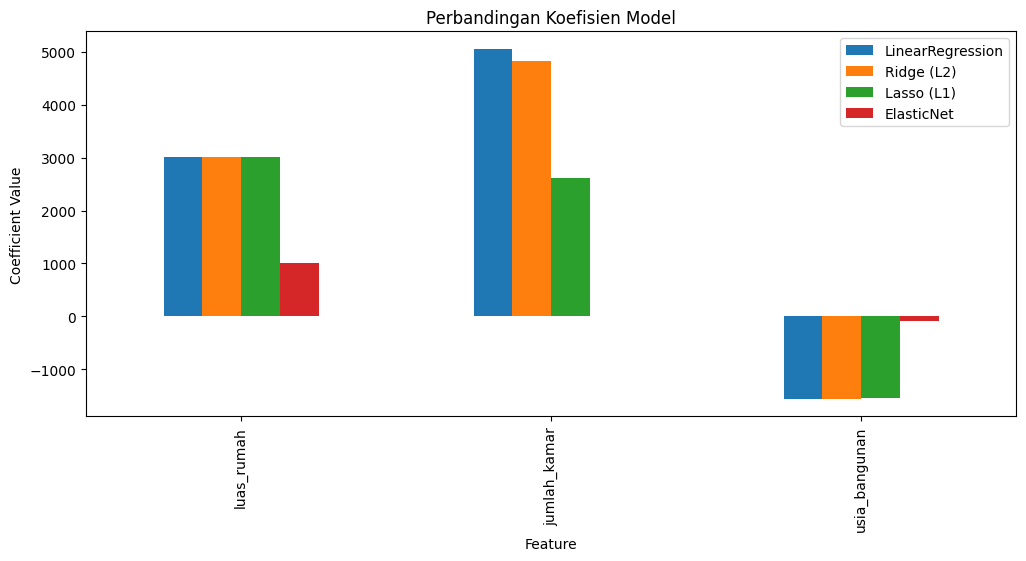

In [55]:
coef_df.plot(x="Feature", kind="bar", figsize=(12,5))
plt.title("Perbandingan Koefisien Model")
plt.ylabel("Coefficient Value")
plt.show()

#### ✔ Apa yang Anda akan lihat:

- LinearRegression → koefisien besar & bebas (raw)
- Ridge → mengecilkan koefisien tapi tidak nol
- Lasso → beberapa koefisien bisa menjadi 0
- ElasticNet → tengah-tengah

### 📉 2. Pengaruh Perubahan α pada Ridge & Lasso

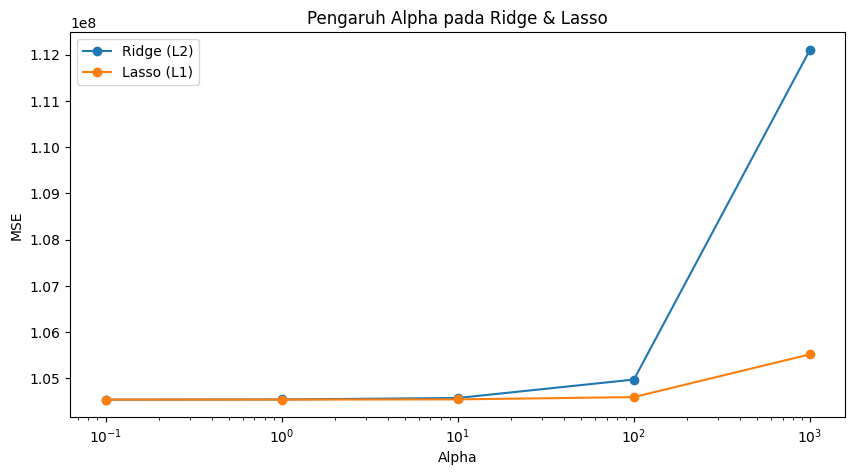

In [56]:
alphas = [0.1, 1, 10, 100, 1000]
ridge_scores = []
lasso_scores = []

from sklearn.metrics import mean_squared_error

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train, y_train)
    lasso = Lasso(alpha=a).fit(X_train, y_train)
    
    ridge_scores.append(mean_squared_error(y_test, ridge.predict(X_test)))
    lasso_scores.append(mean_squared_error(y_test, lasso.predict(X_test)))

plt.figure(figsize=(10,5))
plt.plot(alphas, ridge_scores, marker="o", label="Ridge (L2)")
plt.plot(alphas, lasso_scores, marker="o", label="Lasso (L1)")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Pengaruh Alpha pada Ridge & Lasso")
plt.legend()
plt.show()


✔ Interpretasi:
- α besar → model lebih sederhana → MSE bisa naik/turun
- Ridge stabil, Lasso lebih agresif menghapus fitur

### 🏆 KESIMPULAN REGRESI  
Model	Karakteristik  
LinearRegression	overfitting, koef besar  
Ridge	paling stabil  
Lasso	bisa menghapus fitur sepenuhnya  
ElasticNet	kompromi terbaik

## 🧪 CONTOH KODE PYTHON (Klasifikasi)

Kita buat dataset dummy untuk memprediksi apakah seseorang membeli barang berdasarkan:
- pendapatan
- usia
- jumlah_keluarga

### 📌 A. Membuat Data Dummy (Klasifikasi)

In [57]:
from sklearn.datasets import make_classification

#create simple 3-feature dataset for classification

np.random.seed(42)

pendapatan = np.random.randint(2000, 50000, n)
usia = np.random.randint(17, 65, n)
jumlah_keluarga = np.random.randint(1,6, n)

In [58]:
# target (label) dibuat dengan kombinasi linear + noise
prob = (pendapatan * 0.0001 + usia * -0.02 + jumlah_keluarga * 0.1)
prob = 1 / (1 + np.exp(-prob))  # sigmoid

beli = (prob > 0.5).astype(int)  # threshold

dfc = pd.DataFrame({
    "pendapatan": pendapatan,
    "usia": usia,
    "jumlah_keluarga": jumlah_keluarga,
    "beli": beli
})

In [59]:
dfc.head()

,pendapatan,usia,jumlah_keluarga,beli
0,17795,45,2,1
1,2860,61,3,0
2,40158,45,2,1
3,46732,46,3,1
4,13284,32,2,1


In [60]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   pendapatan       1258 non-null   int32
 1   usia             1258 non-null   int32
 2   jumlah_keluarga  1258 non-null   int32
 3   beli             1258 non-null   int64
dtypes: int32(3), int64(1)
memory usage: 24.7 KB


### 📌 B. Split Data

In [61]:
X = dfc.drop("beli", axis=1)
y = dfc["beli"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 🔵 1. Logistic Regression dengan L2 (default)

In [62]:
from sklearn.linear_model import LogisticRegression

model_l2 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=500)
model_l2.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [63]:
print("Accuracy L2:", model_l2.score(X_test, y_test))
print("Coef L2:", model_l2.coef_)

Accuracy L2: 1.0
Coef L2: [[ 3.14918838e-03 -6.63710948e-01  3.21257452e+00]]


### 🔴 2. Logistic Regression L1 (feature selection)

In [64]:
model_l1 = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=500)
model_l1.fit(X_train, y_train)

LogisticRegression(max_iter=500, penalty='l1', solver='liblinear')

In [65]:
print("Accuracy L1:", model_l1.score(X_test, y_test))
print("Coef L1:", model_l1.coef_)

Accuracy L1: 1.0
Coef L1: [[ 2.42193270e-03 -4.96619094e-01  2.64640364e+00]]


✔ Penjelasan:
- Beberapa koefisien mungkin menjadi 0
- Fitur tersebut dianggap tidak penting oleh model

### 🟧 3. Logistic Regression ElasticNet

In [66]:
model_en = LogisticRegression(
    penalty='elasticnet',
    l1_ratio=0.5,
    solver='saga',
    max_iter=1000
)
model_en.fit(X_train, y_train)

c:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(l1_ratio=0.5, max_iter=1000, penalty='elasticnet',
                   solver='saga')

In [67]:
print("Accuracy EN:", model_en.score(X_test, y_test))
print("Coef EN:", model_en.coef_)

Accuracy EN: 0.9126984126984127
Coef EN: [[ 2.10096570e-04 -1.51867635e-03 -2.68011068e-05]]


### 🎯 RINGKASAN SINGKAT
Metode	Ciri	Manfaat  
Ridge (L2)	Mengecilkan koefisien	Stabil, bagus untuk fitur berkorelasi  
Lasso (L1)	Koef bisa = 0	Melakukan feature selection otomatis  
ElasticNet	Kombinasi L1 + L2	Seimbang antara stabilitas & seleksi fitur  

### 🎨 1. Visualisasi Koefisien Logistic Regression (L2, L1, EN)

In [68]:
from sklearn.linear_model import LogisticRegression

model_l2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=800)
model_l2.fit(X_train, y_train)

model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=800)
model_l1.fit(X_train, y_train)

model_en = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    max_iter=1000
).fit(X_train, y_train)

c:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [69]:
coef_clf = pd.DataFrame({
    "Feature": X.columns,
    "L2": model_l2.coef_[0],
    "L1": model_l1.coef_[0],
    "ElasticNet": model_en.coef_[0]
})

coef_clf

,Feature,L2,L1,ElasticNet
0,pendapatan,0.003149,0.002175,0.000210
1,usia,-0.663711,-0.446806,-0.001518
2,jumlah_keluarga,3.212575,2.394175,-0.000027


### 📊 Visualisasi

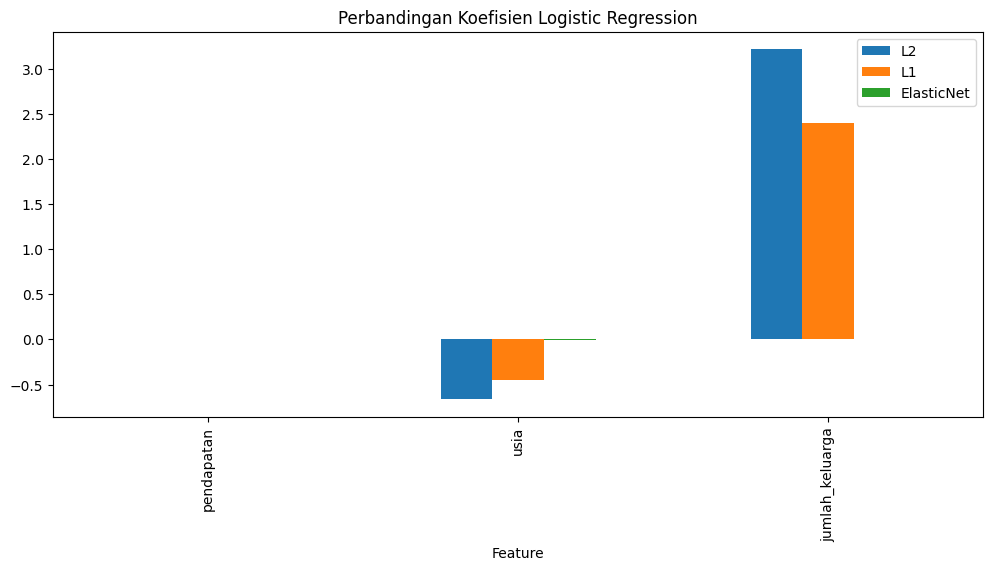

In [70]:
coef_clf.plot(x="Feature", kind="bar", figsize=(12,5))
plt.title("Perbandingan Koefisien Logistic Regression")
plt.show()

### 📉 2. Performa vs Alpha untuk Logistic Regression

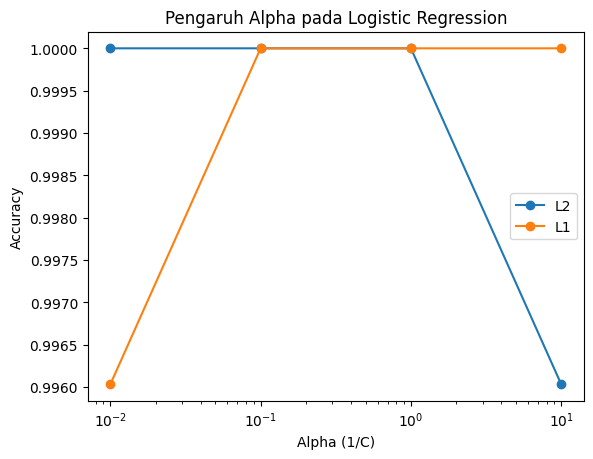

In [71]:
alphas = [0.01, 0.1, 1, 10]
scores_l2 = []
scores_l1 = []

for a in alphas:
    clf_l2 = LogisticRegression(penalty='l2', C=1/a, solver='lbfgs', max_iter=800).fit(X_train, y_train)
    clf_l1 = LogisticRegression(penalty='l1', C=1/a, solver='liblinear', max_iter=800).fit(X_train, y_train)
    
    scores_l2.append(clf_l2.score(X_test, y_test))
    scores_l1.append(clf_l1.score(X_test, y_test))

plt.plot(alphas, scores_l2, marker="o", label="L2")
plt.plot(alphas, scores_l1, marker="o", label="L1")
plt.xscale("log")
plt.xlabel("Alpha (1/C)")
plt.ylabel("Accuracy")
plt.title("Pengaruh Alpha pada Logistic Regression")
plt.legend()
plt.show()


### 🏆 KESIMPULAN KLASIFIKASI
Model	Karakter
- L2	stabil, default terbaik
- L1	melakukan feature selection
- ElasticNet	fleksibel, cocok jika fitur banyak